In [27]:
import matplotlib.pyplot as plt
from arch import arch_model
import pandas_ta
import pandas as pd 
import numpy as np 
import os
import matplotlib.ticker as mtick


In [3]:
df=pd.read_csv('simulated_daily_data.csv')

In [4]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Unnamed: 7
0,9/17/2014,116.466003,117.043503,113.105499,114.333504,114.333504,21056800.0,NaN
1,9/18/2014,114.214996,114.214996,103.276001,106.110001,106.110001,34483200.0,NaN
2,9/19/2014,106.025749,106.958748,96.133003,98.698998,98.698998,37919700.0,NaN
3,9/20/2014,98.668251,105.823998,97.470749,102.225998,102.225998,36863600.0,NaN
4,9/21/2014,102.021248,103.106499,98.295250,99.705254,99.705254,26580100.0,NaN


In [5]:
df=df.drop('Unnamed: 7', axis =1)

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [7]:
df2=pd.read_csv('simulated_5min_data.csv')

In [8]:
df2.head()

,datetime,open,low,high,close,volume,Unnamed: 6
0,9/29/2021 20:00,10379.7775,10364.5950,10398.7025,10370.9575,46,NaN
1,9/29/2021 20:05,10370.9425,10352.4175,10380.2500,10371.1450,53,NaN
2,9/29/2021 20:10,10372.8150,10357.8250,10388.7500,10384.3125,116,NaN
3,9/29/2021 20:15,10385.8275,10384.0825,10457.2000,10442.5175,266,NaN
4,9/29/2021 20:20,10442.5225,10426.2375,10448.0000,10440.9950,65,NaN


In [9]:
df2=df2.drop('Unnamed: 6', axis =1)

In [10]:
df2['datetime'] = pd.to_datetime(df2['datetime'])
df2 = df2.set_index('datetime')
df2['date'] = pd.to_datetime(df2.index.date)

In [12]:
df['log_ret'] = np.log(df['Adj Close']).diff()
df['variance'] = df['log_ret'].rolling(180).var()

In [14]:
df = df['2022':]

In [15]:
def predict_volatility(x):
    
    model = arch_model(y=x,p=1,q=3).fit(update_freq=5,disp='off')
    variance_forecast = model.forecast(horizon=1).variance.iloc[-1,0]

    print(x.index[-1])
    
    return variance_forecast

In [16]:
df['predictions'] = df['log_ret'].rolling(180).apply(lambda x: predict_volatility(x))
df = df.dropna()

/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001397. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


2022-06-29 00:00:00
2022-06-30 00:00:00
2022-07-01 00:00:00
2022-07-02 00:00:00
2022-07-03 00:00:00
2022-07-04 00:00:00


/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001391. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001394. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/python3

2022-07-05 00:00:00
2022-07-06 00:00:00
2022-07-07 00:00:00
2022-07-08 00:00:00
2022-07-09 00:00:00
2022-07-10 00:00:00
2022-07-11 00:00:00


/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001391. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001408. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/python3

...

/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0005336. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0005338. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/pyt

2023-09-06 00:00:00
2023-09-07 00:00:00
2023-09-08 00:00:00
2023-09-09 00:00:00
2023-09-10 00:00:00
2023-09-11 00:00:00


/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004788. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004366. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/pyt

2023-09-12 00:00:00
2023-09-13 00:00:00
2023-09-14 00:00:00
2023-09-15 00:00:00
2023-09-16 00:00:00
2023-09-17 00:00:00
2023-09-18 00:00:00


/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003913. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003828. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/python/3.12.1/lib/pyt

In [17]:
df

,Open,High,Low,Close,Adj Close,Volume,log_ret,variance,predictions
Date,,,,,,,,,
2022-06-29,5070.292480,5091.039063,4984.447754,5026.005859,5026.005859,2.355274e+10,-0.008747,0.001405,0.001950
2022-06-30,5027.078125,5035.290039,4682.414063,4946.181641,4946.181641,2.626724e+10,-0.016010,0.001399,0.001848
2022-07-01,4955.117676,5158.167969,4768.427246,4817.341797,4817.341797,3.076755e+10,-0.026394,0.001402,0.001879
2022-07-02,4818.708984,4842.937012,4756.770508,4810.563965,4810.563965,1.810042e+10,-0.001408,0.001401,0.001857
2022-07-03,4810.523926,4889.567383,4741.737793,4824.269043,4824.269043,1.639082e+10,0.002845,0.001401,0.001810
...,...,...,...,...,...,...,...,...,...
2023-09-14,6557.069336,6693.655762,6542.862793,6634.918457,6634.918457,1.381136e+10,0.011801,0.000393,0.000334
2023-09-15,6633.454590,6710.124512,6560.175293,6652.173340,6652.173340,1.147974e+10,0.002597,0.000385,0.000292
2023-09-16,6651.549805,6688.692383,6618.472656,6642.070313,6642.070313,7.402031e+09,-0.001520,0.000384,0.000286


In [19]:
df['prediction_premium'] = (df['predictions']-df['variance'])/df['variance']
df['premium_std'] = df['prediction_premium'].rolling(180).std()

df['signal_daily'] = df.apply(lambda x: 1 if (x['prediction_premium']>x['premium_std'])
                                         else (-1 if (x['prediction_premium']<x['premium_std']*-1) else np.nan),
                                         axis=1)

df['signal_daily'] = df['signal_daily'].shift()

In [20]:
df

,Open,High,Low,Close,Adj Close,Volume,log_ret,variance,predictions,prediction_premium,premium_std,signal_daily
Date,,,,,,,,,,,,
2022-06-29,5070.292480,5091.039063,4984.447754,5026.005859,5026.005859,2.355274e+10,-0.008747,0.001405,0.001950,0.388179,NaN,NaN
2022-06-30,5027.078125,5035.290039,4682.414063,4946.181641,4946.181641,2.626724e+10,-0.016010,0.001399,0.001848,0.321147,NaN,NaN
2022-07-01,4955.117676,5158.167969,4768.427246,4817.341797,4817.341797,3.076755e+10,-0.026394,0.001402,0.001879,0.340345,NaN,NaN
2022-07-02,4818.708984,4842.937012,4756.770508,4810.563965,4810.563965,1.810042e+10,-0.001408,0.001401,0.001857,0.325725,NaN,NaN
2022-07-03,4810.523926,4889.567383,4741.737793,4824.269043,4824.269043,1.639082e+10,0.002845,0.001401,0.001810,0.292345,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-14,6557.069336,6693.655762,6542.862793,6634.918457,6634.918457,1.381136e+10,0.011801,0.000393,0.000334,-0.151791,0.555509,NaN
2023-09-15,6633.454590,6710.124512,6560.175293,6652.173340,6652.173340,1.147974e+10,0.002597,0.000385,0.000292,-0.240812,0.552702,NaN
2023-09-16,6651.549805,6688.692383,6618.472656,6642.070313,6642.070313,7.402031e+09,-0.001520,0.000384,0.000286,-0.256794,0.552700,NaN


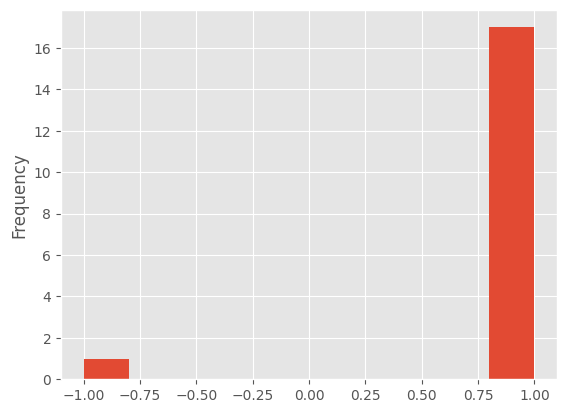

In [21]:
plt.style.use('ggplot')
df['signal_daily'].plot(kind='hist')
plt.show()

In [23]:
final_df = df2.reset_index()\
    .merge(df[['signal_daily']].reset_index(),left_on='date',right_on='Date')\
        .drop(['date','Date'], axis=1)\
            .set_index('datetime')

final_df['rsi'] = pandas_ta.rsi(close=final_df['close'],length=20)

final_df['lband'] = pandas_ta.bbands(close=final_df['close'],length=20).iloc[:,0]

final_df['uband'] = pandas_ta.bbands(close=final_df['close'],
                                     length=20).iloc[:,2]

final_df['signal_intraday'] = final_df.apply(lambda x: 1 if (x['rsi']>70)&
                                                            (x['close']>x['uband'])
                                             else (-1 if (x['rsi']<30)&
                                                         (x['close']<x['lband']) else np.nan),
                                             axis=1)

final_df['return'] = np.log(final_df['close']).diff()



In [24]:
final_df

,open,low,high,close,volume,signal_daily,rsi,lband,uband,signal_intraday,return
datetime,,,,,,,,,,,
2022-06-29 00:00:00,5064.0650,5062.5025,5075.000000,5067.5875,25,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-29 00:05:00,5068.2075,5061.2750,5076.750000,5072.1350,50,NaN,100.000000,NaN,NaN,NaN,0.000897
2022-06-29 00:10:00,5070.9000,5069.5225,5084.750000,5078.0225,49,NaN,100.000000,NaN,NaN,NaN,0.001160
2022-06-29 00:15:00,5078.1750,5071.4400,5081.500000,5072.3675,25,NaN,93.940887,NaN,NaN,NaN,-0.001114
2022-06-29 00:20:00,5072.5000,5056.2525,5077.185917,5058.9425,51,NaN,81.587385,NaN,NaN,NaN,-0.002650
...,...,...,...,...,...,...,...,...,...,...,...
2023-09-18 23:35:00,6708.0025,6705.5175,6712.000000,6708.8675,11,NaN,62.861699,6676.865107,6716.355393,NaN,0.000128
2023-09-18 23:40:00,6708.8650,6707.1800,6714.250000,6709.3350,22,NaN,63.165869,6679.063405,6717.040595,NaN,0.000070
2023-09-18 23:45:00,6709.9250,6704.3600,6713.500000,6708.2750,25,NaN,61.954798,6681.936281,6716.977719,NaN,-0.000158


In [25]:
final_df['return_sign'] = final_df.apply(lambda x: -1 if (x['signal_daily']==1)&(x['signal_intraday']==1)
                                        else (1 if (x['signal_daily']==-1)&(x['signal_intraday']==-1) else np.nan),
                                        axis=1)

final_df['return_sign'] = final_df.groupby(pd.Grouper(freq='D'))['return_sign']\
                                  .transform(lambda x: x.ffill())

final_df['forward_return'] = final_df['return'].shift(-1)

final_df['strategy_return'] = final_df['forward_return']*final_df['return_sign']

daily_return_df = final_df.groupby(pd.Grouper(freq='D'))['strategy_return'].sum()

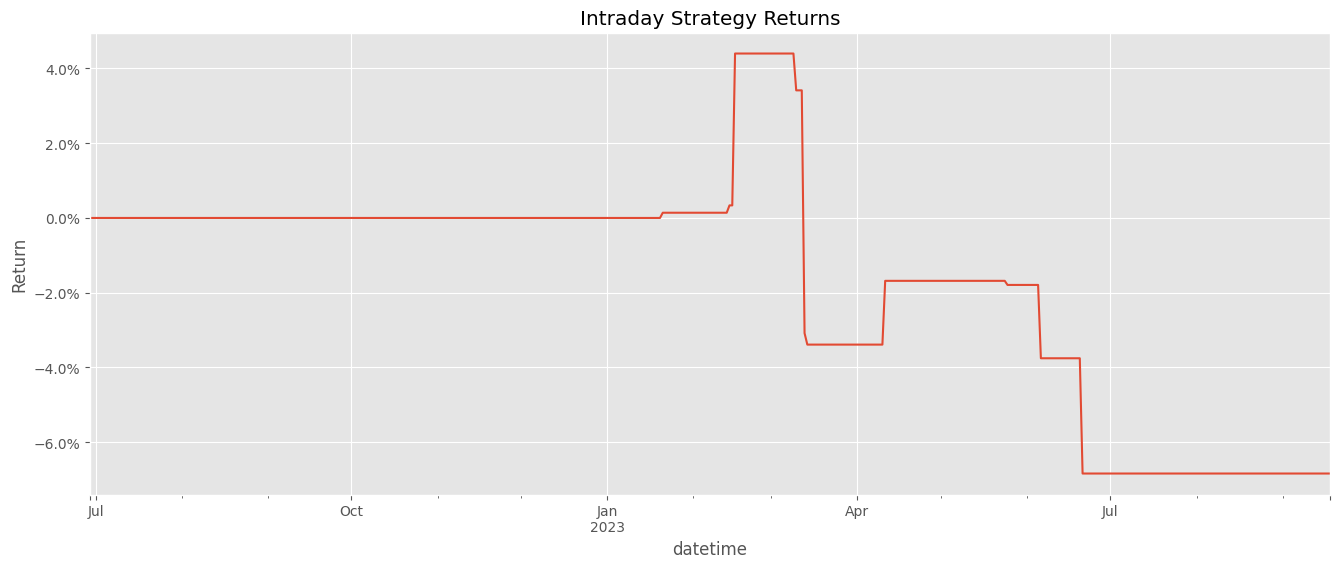

In [28]:
strategy_cumulative_return = np.exp(np.log1p(daily_return_df).cumsum()).sub(1)

strategy_cumulative_return.plot(figsize=(16,6))

plt.title('Intraday Strategy Returns')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()